# Nan analysis of the 5min pv data

This notebook does analysis for nan values in 5min PV data.

The following questions are answered:

1. How many nan values are there w.r.t. time?
2. What is the number of pv system w.r.t. time?
3. How much power is generated w.r.t. time?

# Preprocessing

In [ ]:
# !pip install vaex

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vaex as vx
from datetime import datetime
from datetime import time

## Data

The [5min](https://huggingface.co/datasets/openclimatefix/uk_pv/blob/main/5min.parquet) dataset was used. This is PV solar generation data from the UK.

In [2]:
data = vx.open('5min.parquet')  
data['day'],data['month'],data['year'] = data.timestamp.dt.day, data.timestamp.dt.month,data.timestamp.dt.year,
data['hour'],data['minute'],data['second'] = data.timestamp.dt.hour,  data.timestamp.dt.minute, data.timestamp.dt.second
data['time'] = data.hour.astype(str)+ ':'+ data.minute.astype(str) 

In [3]:
data.head()

#,generation_wh,timestamp,ss_id,day,month,year,hour,minute,second,time
0,0,2018-04-01 03:05:00+00:00,2607,1,4,2018,3,5,0,3:5
1,0,2018-04-01 03:05:00+00:00,2625,1,4,2018,3,5,0,3:5
2,0,2018-04-01 03:05:00+00:00,2626,1,4,2018,3,5,0,3:5
3,0,2018-04-01 03:05:00+00:00,2631,1,4,2018,3,5,0,3:5
4,0,2018-04-01 03:05:00+00:00,2657,1,4,2018,3,5,0,3:5
5,0,2018-04-01 03:05:00+00:00,2660,1,4,2018,3,5,0,3:5
6,0,2018-04-01 03:05:00+00:00,2729,1,4,2018,3,5,0,3:5
7,0,2018-04-01 03:05:00+00:00,2760,1,4,2018,3,5,0,3:5
8,0,2018-04-01 03:05:00+00:00,2766,1,4,2018,3,5,0,3:5
9,0,2018-04-01 03:05:00+00:00,2770,1,4,2018,3,5,0,3:5


In [9]:
print("The number of unique ss_id in 5min : ",len(data.ss_id.unique()))

The number of unique ss_id in 5min :  1311


Creating a column which checks whether generation_wh column is NaN.

In [5]:
data['is_nan'] = data['generation_wh'].isna()

Creating a dataframe for plotting NaN values

In [10]:
min5_selected = data[['is_nan','month','year','day']] 
per_hour_season = min5_selected.groupby(['year','month','day']).agg({'is_nan': 'sum'}).to_pandas_df()
per_hour_season['year_month'] = pd.to_datetime(per_hour_season[['year', 'month']].assign(day=1))

In [11]:
per_hour_season.head()

,year,month,day,is_nan,year_month
0,2018,1,1,0,2018-01-01
1,2018,1,2,0,2018-01-01
2,2018,1,3,0,2018-01-01
3,2018,1,4,0,2018-01-01
4,2018,1,5,0,2018-01-01


Creating a dataframe to plot generated power and number of PV system with time.

In [12]:
df2 = data.groupby(['day', 'month', 'year']).agg({
    'generation_wh': ['sum', 'count']
     })
df2 = df2.to_pandas_df()
df2['date'] = pd.DataFrame(pd.to_datetime(df2[['year', 'month', 'day']]))


In [13]:
df2.head()

,day,month,year,generation_wh_sum,generation_wh,date
0,1,1,2018,1.631470e+06,159576,2018-01-01
1,1,1,2019,1.967764e+06,294230,2019-01-01
2,1,1,2020,8.330046e+05,265495,2020-01-01
3,1,1,2021,1.134886e+06,239579,2021-01-01
4,1,2,2018,4.208096e+06,157500,2018-02-01


# Plots

## NaN value count v/s time 

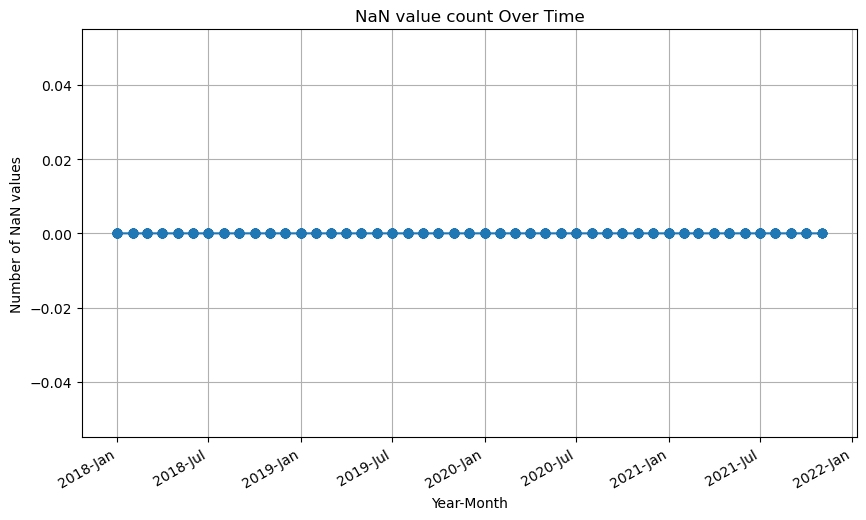

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(per_hour_season['year_month'], per_hour_season['is_nan'], marker='o')

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%b'))  
plt.gcf().autofmt_xdate() 

plt.xlabel('Year-Month')
plt.ylabel('Number of NaN values')
plt.title('NaN value count Over Time')
plt.grid(True)
plt.show()

In [17]:
print("Number of NaN entries for power generated : ",data['generation_wh'].isnan().sum().item())

Number of NaN entries for power generated :  0


There are no Nan values in generated power column.

## PV system count v/s time 

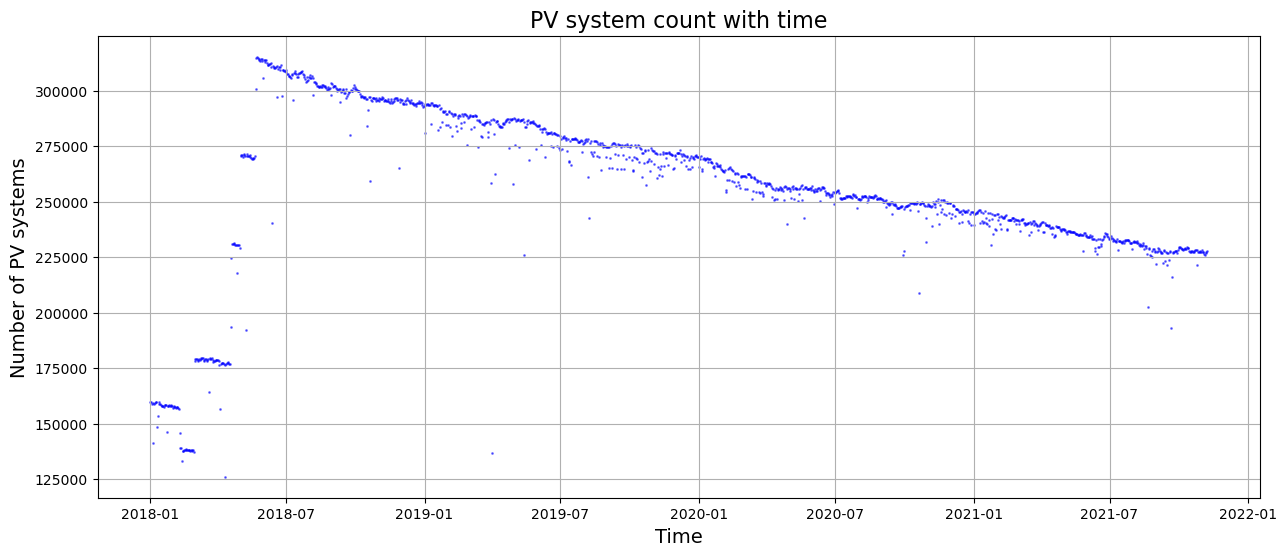

In [18]:
plt.figure(figsize=(15, 6))
plt.scatter(x=df2['date'], y=df2['generation_wh'], s=1, alpha=0.5, color='blue')  
plt.title("PV system count with time", fontsize=16)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Number of PV systems", fontsize=14)
plt.grid(True)
plt.show()

We can see there is step wise increase in 2018 which could denote installation of new power plant. <br>
Also, there is general decrease in number of data points with time. This could be because of damage in solar panels.

## Power generated per day v/s time 

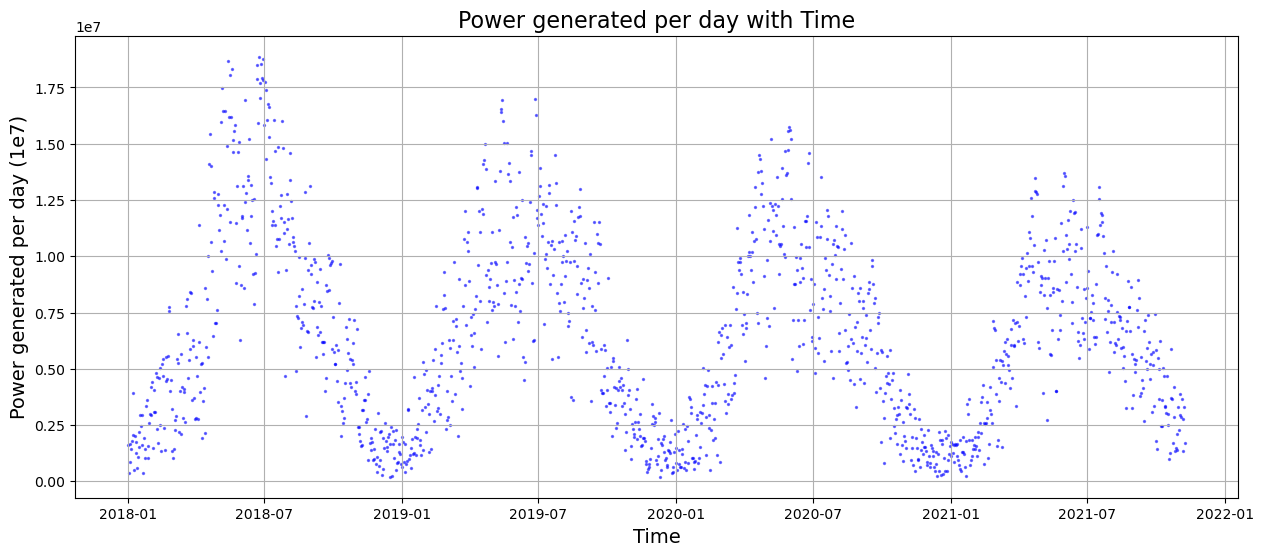

In [19]:

plt.figure(figsize=(15, 6))
plt.scatter(df2['date'], df2['generation_wh_sum'], s=2, alpha=0.5, color='blue')
plt.title("Power generated per day with Time", fontsize=16)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Power generated per day (1e7)", fontsize=14)
plt.grid(True)
plt.show()

We can see power output increase and decrease with change in seasons.